In [20]:
from functions.internal import load_dataset_1B, normalization
from functions.SQUIC_functions import squic_fit_matrix_computation, squic_fit_computation, check_symmetric_sparse
from functions.clustering_functions import clustering_optimal_number, modularity_density, study_CC
from functions.plots import plot_timeseries, plot_knn, plot_PDens_Q
from functions.cosmograph_functions import visualize_graph_external
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
import json
from scipy import sparse
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np
import os

In [21]:
def show_df(Y):
    n_users, n_days = Y.shape

    # Create labels
    day_labels = [f"Day {i}" for i in range(n_days)]
    user_labels = list(range(n_users))

    # Create the DataFrame
    df = pd.DataFrame(Y, index=user_labels, columns=day_labels)

    print(df)


def ask_yes_no(prompt, default=None):
    """
    Ask the user a yes/no question with optional default.
    """
    while True:
        answer = input(f"{prompt} (Y/N) ").strip().upper()
        if not answer and default:
            return default
        if answer in ['Y', 'N']:
            return answer
        print("Please enter 'Y' or 'N'.")


def ask_input(prompt, default=None):
    """
    Ask the user for input with optional default.
    """
    answer = input(f"{prompt} ").strip()
    if not answer and default is not None:
        return default
    return answer

In [22]:
user_input = ask_yes_no("\nDo you want to load data?")

if user_input == 'Y':
    dimension = ask_input("Which dimension (100/1K/10K/100K/1M)?").upper()
    path = 'amlsim_data_saved'

    try:
        # Load pre-saved Y_norm
        chunk_size = 10000
        chunks = []

        for chunk in pd.read_csv(f'{path}/YNorm_{dimension}.csv', chunksize=chunk_size):
            chunks.append(chunk)

        Y_norm = pd.concat(chunks, ignore_index=True)

        print(f"Head of Y_norm df:")
        print(Y_norm.head())
        print(f"\ndimension of YNorm loaded: {Y_norm.shape}")

        std_dev = round(np.mean(np.std(Y_norm, axis=1)), 2)

        print("Mean std per row (should be 1):", std_dev)
        print("Max:", np.max(Y_norm))
        print("Min:", np.min(Y_norm))

        # Load pre-saved knn_matrix
        knn_matrix = sparse.load_npz(f'{path}/knn_matrix_{dimension}.npz')

        print("Shape KNN:", knn_matrix.shape)
        print("nnz KNN:", knn_matrix.nnz)

        # Average number of non-zeros per row
        nnz_per_row = knn_matrix.nnz / knn_matrix.shape[0]
        print("nnz per row:", round(nnz_per_row, 2))
        print("Is symmetric:", check_symmetric_sparse(knn_matrix))

        # Load pre-saved account_properties
        with open(f'{path}/account_prop_{dimension}.json', 'r') as f:
            account_prop = json.load(f)

        account_prop = {int(k): v for k, v in account_prop.items()}
        
        name = 'AMLSIM'

    except Exception as e:
        # If data are not present
        print(f"Error loading data: {e}")
        exit(1)
    
else: # Normal run
    Y, name, dimension, account_prop = load_dataset_1B()

    plot_timeseries(Y, name)

    Y = Y.T.values  # Convert to (users, days)

    show_df(Y)


    Y_norm = normalization(Y, name)
    plot_timeseries(Y_norm, name, type_df='norm')

    show_df(Y_norm)
    print(f"\ndimension of YNorm loaded: {Y_norm.shape}")

    std_dev = round(np.mean(np.std(Y_norm, axis=1)), 2)

    print("Mean std per row (should be 1):", std_dev)
    print("Max:", np.max(Y_norm))
    print("Min:", np.min(Y_norm))

    n_neigs = {
        '100' : 10,
        '1K' : 5,
        '10K' : 5,
        '100K' : 4,
        '1M' : 3
    }

    nbrs = NearestNeighbors(n_neighbors=n_neigs[dimension], metric='euclidean', n_jobs=-1)
    nbrs.fit(Y_norm)
    knn_matrix = nbrs.kneighbors_graph(Y_norm, mode='connectivity')

    print("Shape KNN:", knn_matrix.shape)
    print("nnz KNN:", knn_matrix.nnz)

    # Average number of non-zeros per row
    nnz_per_row = knn_matrix.nnz / knn_matrix.shape[0]
    print("nnz per row:", round(nnz_per_row, 2))
    print("Is symmetric:", check_symmetric_sparse(knn_matrix))

    
    # Ask user if want to save the data for next runs
    if ask_yes_no("Do you want to cache this data?") == 'Y':
        path = 'amlsim_data_saved'

        # if path does not exists, create it
        os.makedirs(path, exist_ok=True)
        
        # Save Y_norm as CSV
        pd.DataFrame(Y_norm).to_csv(f'{path}/YNorm_{dimension}.csv', index=False)
        
        # Save account_prop as json
        with open(f'{path}/account_prop_{dimension}.json', 'w') as f:
            json.dump(account_prop, f)
        
        # Save knn_matrix as npz
        sparse.save_npz(f'{path}/knn_matrix_{dimension}.npz', knn_matrix)

Head of Y_norm df:
            0           1           2           3           4           5  \
0  184.440000  184.440000  184.440000  184.440000  184.440000  184.440000   
1    0.153330    0.153330    0.153330    0.153330    0.153330    0.153330   
2    0.182678    0.182678    0.182678    0.182678    0.182678    0.182678   
3    0.214058    0.214058    0.214058    0.214058    0.214058    0.214058   
4    0.168818    0.168818    0.168818    0.168818    0.168818    0.168818   

            6           7           8           9  ...         190  \
0  184.440000  184.440000  184.440000  184.440000  ...  184.440000   
1    0.000000    0.000000    0.000000    0.000000  ...   -3.066594   
2    0.182678    0.182678    0.182678    0.182678  ...   -2.739970   
3    0.214058    0.214058    0.214058    0.214058  ...   -2.891597   
4    0.168818    0.168818    0.168818    0.168818  ...   -3.207538   

          191         192         193         194         195         196  \
0  184.440000  184.4

In [23]:
results_squic = {}

# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':

    os.makedirs(f'images/{dimension}/', exist_ok=True)

    if ask_yes_no("Do you want to visualize the results of SQUIC-Fit?") == 'Y':
        printMatrix = True

        # Print knn matrix
        plt.figure(figsize=(7, 7))
        plt.spy(knn_matrix, markersize=5)
        plt.ylabel("Users", fontsize=18)
        plt.show()
    else:
        printMatrix = False

    if ask_yes_no("Do you want to save the results of SQUIC-Fit?") == 'Y':
        save = True
    else:
        save = False
    
    if printMatrix:
        plot_knn(knn_matrix, dimension, save)
    
    squic_method = 'squic-fit-matrix'
    results_squic[squic_method] = squic_fit_matrix_computation(Y_norm, name, dimension, knn_matrix, printMatrix, save)

else:
    if ask_yes_no("Do you want to visualize the results of SQUIC-Fit?") == 'Y':
        printMatrix = True
    else:
        printMatrix = False

    if ask_yes_no("Do you want to save the results of SQUIC-Fit?") == 'Y':
        save = True
    else:
        save = False

    squic_method = 'squic-fit'
    results_squic[squic_method] = squic_fit_computation(Y_norm, name, dimension, printMatrix, save)


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    8.418600e+00
 Y:         10000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999990e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=5.82e+00 time=9.70e-02
* iter=1 time=5.87e-02 obj=1.76e+04 |delta(obj)|/obj=4.32e-01 nnz(X,L,W)/p=[5.82e+00 3.61e+01 1.05e+00] lns_iter=4 
* iter=2 time=1.06e-01 obj=1.69e+04 |delta(obj)|/obj=3.97e-02 nnz(X,L,W)/p=[5.82e+00 3.61e+01 3.33e+01] lns_iter=5 
* iter=3 time=4.73e-01 obj=1.61e+04 |

Is G connected for l=0.999999? False
# CC : 141
Is G connected for l=0.999995? False
# CC : 135
Is G connected for l=0.99999? False
# CC : 134
Attempt 1 failed: ARPACK error -1: No convergence (1001 iterations, 7/13 eigenvectors converged)
For rho 0.999999:
    louvain: PDensity = 0.02, Int Density = 0.23, Q = 0.89, nCluster = 180, nIsolated  = 119
    leiden: PDensity = 0.03, Int Density = 0.22, Q = 0.9, nCluster = 208, nIsolated  = 119
    dbscan: PDensity = 0.01, Int Density = 0.07, Q = 0.04, nCluster = 642, nIsolated  = 585
    spectral: PDensity = 0.0, Int Density = 0.26, Q = 0.01, nCluster = 6, nIsolated  = 0
For rho 0.999995:
    louvain: PDensity = 0.02, Int Density = 0.24, Q = 0.88, nCluster = 179, nIsolated  = 115
    leiden: PDensity = 0.03, Int Density = 0.2, Q = 0.9, nCluster = 197, nIsolated  = 115
    dbscan: PDensity = 0.01, Int Density = 0.07, Q = 0.04, nCluster = 634, nIsolated  = 580
    spectral: PDensity = 0.0, Int Density = 0.44, Q = 0.01, nCluster = 7, nIsolated 

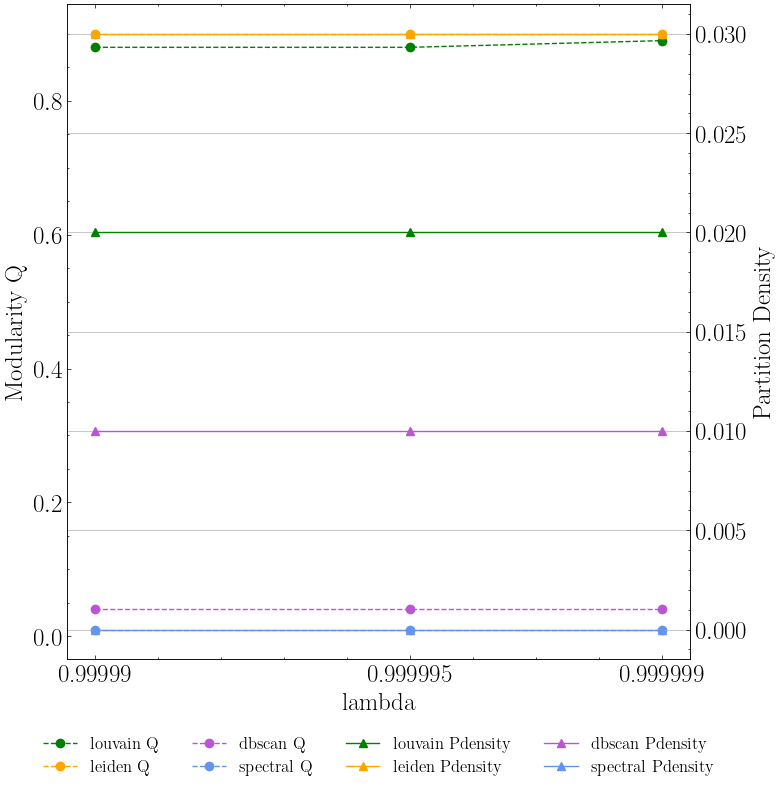

In [24]:
# Results
dict_cluster = clustering_optimal_number(dimension, results_squic, plot=False)

metrics = modularity_density(dict_cluster, results_squic, leiden=True)

for rho, data in metrics.items():
    print(f"For rho {rho}:")
    for method, results in data.items():
        print(f"    {method}: PDensity = {results['p_density']}, Int Density = {results['int_density']}, Q = {results['modularity']}, nCluster = {results['nCluster']}, nIsolated  = {results['isolated']}")

plot_PDens_Q(name, metrics, dimension, squic_method, save)

In [25]:
graph = visualize_graph_external(results_squic, squic_method, dict_cluster, account_prop)

In [28]:
lambda_graph = {
    '100': 0.09,
    '1K': 0.9999,
    '10K': 0.999999,
    '100K': 0.99999999
}

In [29]:
graph[lambda_graph.get(dimension)]['leiden']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…